In [137]:
import importlib

import analysis_helpers
from analysis_helpers import open_models

"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import logging
from datetime import datetime

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# PARAMETERS
classifications_csv_path = '../4_survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = '../media/'
prompts_path = '../1_input_prompts/prompts.json'
full_prompts_excel = '../1_input_prompts/20250504_prompts.xlsx'
ml_responses_database_path = '../2_retrieved_responses/records.db'
subjects_path = '../4_survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b'] # Deepseek-r1 was run with two inference platforms. We retain the results for the deepseek model with more parameters for a fair comparison

In [138]:
sns.set_theme(style="darkgrid")

In [141]:
prompts_full = pd.read_excel(full_prompts_excel)

In [153]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


In [154]:
importlib.reload(analysis_helpers)

combined_final = analysis_helpers.load_raw(classifications_csv_path, subjects_path, prompts_json_path=prompts_path, exclude_models=exclude_models, exclude_prompt_ids=exclude_prompts, workflow_id=workflow_id)

In [155]:
combined_final.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'prompt_text', 'T2_score',
       'T3_score', 'T4_score', 'T12_score', 'count_citations'],
      dtype='object')

In [156]:
combined_final.response_id = combined_final.response_id.astype(int)

In [157]:
import sqlite3
conn = sqlite3.connect(ml_responses_database_path)
ml_responses = pd.read_sql('select * from responses', conn)
combined_final_with_response = combined_final.merge(ml_responses[['id','response_text']],left_on='response_id',right_on='id', how='left')

In [158]:
prompts_full

,ID,LCA stage,Task_type,Problem_type,Prompt,Answer,Explanation,Extra_remarks
0,1,Interpretation,Fact answering in LCA,Multiple choice question answering,This question is about materials used to make ...,A,Answer: A. The fact that the paper plate is bi...,NaN
1,2,Interpretation,Fact answering in LCA,Multiple choice question answering,Which of the following is not an example of a ...,D,Answer: D. The life cycle of moths falls outsi...,NaN
2,3,Interpretation,Fact answering in LCA,Multiple choice question answering,Which of the following is an example of a ques...,C,Answer: C. Considering each option in term: (A...,NaN
3,4,Interpretation,Fact answering in LCA,Multiple choice question answering,What is not a key requirement that must be spe...,B,"Answer: B, the addresses or other confidential...",NaN
4,5,Interpretation,Fact answering in LCA,Multiple choice question answering,Most industrial processes produce more than th...,A,Answer: A. Source NEN-EN 15804:2012+A2:2019 pp...,NaN
5,6,Goal and scope definition,Goal and scope definition,Short-form text generation,Give a definition the functional unit of a pro...,An example “gold” standard answer (based on LC...,NaN,NaN
6,7,Goal and scope definition,Goal and scope definition,Long-form text generation,An energy company plans to assess the conseque...,NaN,NaN,NaN
7,8,Inventory,Filling data gaps,Long-form text generation,You must conduct an LCA to compare environment...,NaN,NaN,NaN
8,9,Interpretation,Interpretation,Long-form text generation,Two independent LCAs of plant-based meat subst...,NaN,NaN,NaN
9,10,Goal and scope definition,Goal and scope definition,Long-form text generation,The following is an example scenario for a lif...,NaN,NaN,This prompt assess social life cycle assessment


In [159]:
combined_final_with_response = combined_final_with_response.merge(prompts_full,left_on='prompt_id',right_on="ID")

In [167]:

# Group combined_final by prompt_id and # llm_model
grouped_results_tasktype = (combined_final_with_response
.groupby(['Task_type'])
.agg({
    'T2_score':'mean',
    'T3_score':'mean',
    'T4_score':'mean',
    'T12_score':'mean',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'incorrect',
    # 'original_index':'count'
},axis=1))
model_counts = combined_final_with_response.groupby('Task_type').size()

t12_score_rescaled = (1-grouped_results_tasktype['incorrect']) * 3 + 1 # rescale [0,1] to [1,4]
t4_score_rescaled = grouped_results_tasktype['format']*3 + 1 # rescale [0,1] to [1,4]
grouped_results_tasktype['correctness ^']=t12_score_rescaled
grouped_results_tasktype['format ^']=t4_score_rescaled

del grouped_results_tasktype['format'] # remove format column as it is not needed for heatmap plotting
del grouped_results_tasktype['incorrect'] # remove incorrect column as it is not needed for heatmap plotting
mean_acc_expl = grouped_results_tasktype.agg('mean', axis=1)
grouped_results_tasktype['mean'] = mean_acc_expl
grouped_results_tasktype['count reviews'] = model_counts

grouped_results_tasktype

,accuracy,explanation,correctness ^,format ^,mean,count reviews
Task_type,,,,,,
Automated data mapping,2.142857,2.285714,2.285714,3.571429,2.571429,7
Collect LCI data,2.875000,2.500000,3.625000,4.000000,3.250000,8
Fact answering in LCA,2.541667,2.708333,2.687500,3.375000,2.828125,48
Filling data gaps,2.222222,2.666667,3.000000,3.333333,2.805556,9
Goal and scope definition,2.681818,2.681818,2.909091,3.590909,2.965909,22
Impact assessment,2.419355,2.709677,2.645161,3.516129,2.822581,31
Interpretation,2.700000,2.633333,3.300000,3.400000,3.008333,30
Inventory generation,1.833333,2.666667,2.500000,3.500000,2.625000,6
Literature review,1.857143,2.142857,2.714286,2.285714,2.250000,7


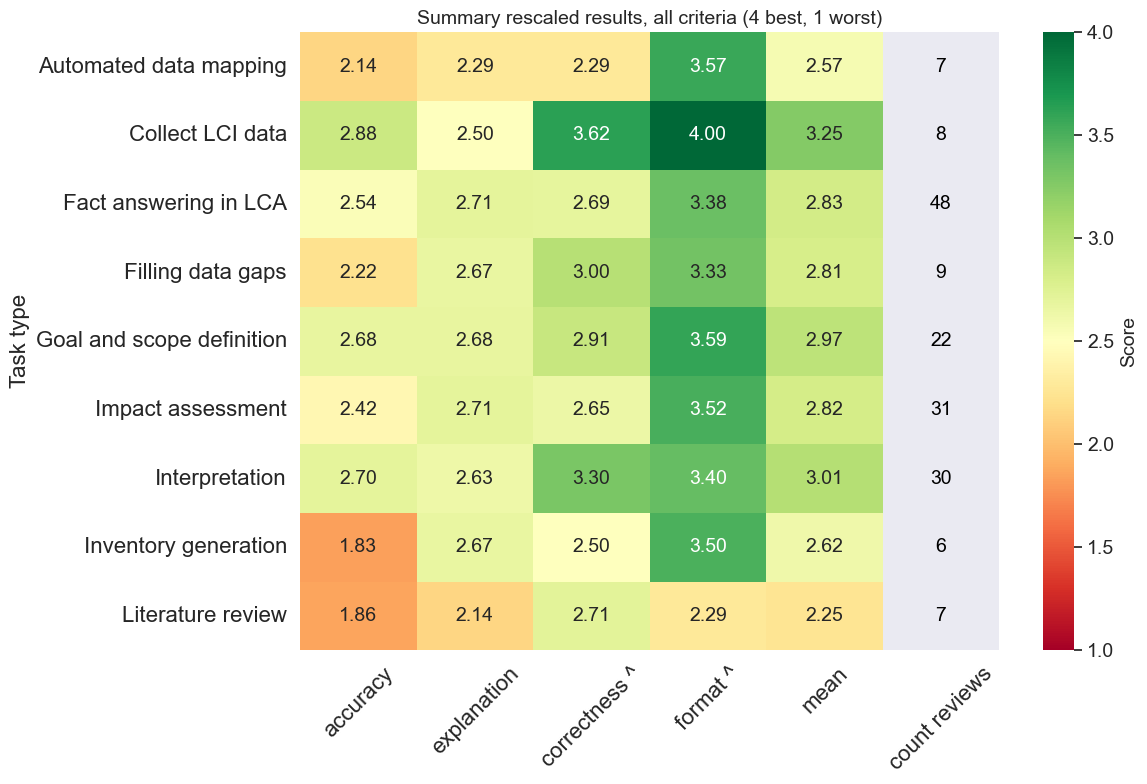

In [169]:
# Create the heatmap
import numpy as np
plt.figure(figsize=(12, 8))

mask = np.zeros(grouped_results_tasktype.shape)
mask[:,-1] = True
ax = sns.heatmap(grouped_results_tasktype, mask=mask, annot=True, cmap='RdYlGn', vmin=1, vmax=4, fmt='.2f',
            cbar_kws={'label': 'Score'},
             annot_kws={"size": 14})
ax.collections[0].colorbar.ax.tick_params(labelsize=14)
ax.collections[0].colorbar.set_label('Score', fontsize=14)

plt.grid(False)
plt.title('Summary rescaled results, all criteria (4 best, 1 worst)',fontsize=14)
plt.xlabel('')
plt.ylabel('Task type', fontsize=16)

# Add missing labels for the masked column
for (j,i), label in np.ndenumerate(grouped_results_tasktype.values):
    if i == grouped_results_tasktype.shape[1]-1:
        ax.text(i+0.5, j+0.5, f'{label:.0f}',
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))

# Add asterisks to x ticks labels for open models
plt.xticks(rotation=45,fontsize=16)
plt.yticks(ax.get_yticks(), rotation=0,ha='right',fontsize=16)

plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_by_task_type.png')
plt.show()

# Hallucination Rate

In [121]:
import analyze_responses_q1
def get_hallucination_rates_by_prompt(combined_final:pd.DataFrame, min_citations:int=7) -> tuple[pd.Series,pd.DataFrame]:
    """Get hallucination rates across models for citation, given the combined dataframe from the `load_raw` function.
    Filter out models where the number of citations is less than `min_citations`.

    Returns:
        summary_citation_types_across_models: A pandas Series of correct citations across models
        summary_citations_by_model: A dataframe with the hallucination rate for each model.
        """
    ##############################################################
    # Analyse Q1 - Citations
    ##############################################################
    # Filter on questions that ask for citations
    combined_final.loc[:, 'expect_citation'] = combined_final.prompt_text.str.contains('citation')
    filtered_q1 = combined_final.loc[combined_final.expect_citation == 1]
    filtered_q1.loc[:, 'count_citations'] = filtered_q1.T1.apply(len)

    # Apply the function to the 'T1' column
    citation_types = filtered_q1['T1'].apply(analyze_responses_q1.count_tool_items)

    # Aggregate the counts for each tool
    count_citation_types_agg = {}
    for counts in citation_types:
        for tool, count in counts.items():
            count_citation_types_agg[tool] = count_citation_types_agg.get(tool, 0) + count

    # Map the tool values to the corresponding results
    tool_number_to_citation_type = {0: 'correct', 1: 'not_exist', 2: 'not_relevant', 3: 'no_access'}

    # Summarize number of correct citations across models
    summary_citation_types_across_models = pd.Series({
        f'T1_{tool_number_to_citation_type.get(tool, "unknown")}': count_citation_types_agg.get(tool, 0)
        for tool in tool_number_to_citation_type
    })

    # Summarize citations per model
    # Summarize the results by type of citation, aggregating on the column '#llm_model'
    summary_by_model_dict = combined_final.groupby('prompt_id', group_keys=False).apply(lambda x: {
        f'T1_{tool_number_to_citation_type.get(tool, "unknown")}': x['T1'].apply(analyze_responses_q1.count_tool_items).apply(
            lambda y: y.get(tool, 0)).sum()
        for tool in tool_number_to_citation_type
    }).to_dict()

    summary_citations_by_model = pd.DataFrame.from_dict(summary_by_model_dict).T
    count_citations = summary_citations_by_model[['T1_correct', 'T1_not_exist', 'T1_not_relevant']].agg('sum', axis=1)
    hallucination_rate = 1 - (summary_citations_by_model.T1_correct / count_citations)
    summary_citations_by_model['count_citations'] = count_citations
    summary_citations_by_model.loc[count_citations >= min_citations, ['Hallucination rate']] = hallucination_rate
    summary_citations_by_model.loc[count_citations < min_citations, ['Hallucination rate']] = None  # not enough evidence
    summary_citations_by_model.sort_values(by='Hallucination rate', ascending=True, inplace=True)
    summary_citations_by_model.index.name = 'PromptId'
    return summary_citation_types_across_models, summary_citations_by_model


In [124]:

summary_citation_types_across_prompts, summary_citations_by_prompt = get_hallucination_rates_by_prompt(combined_final, min_citations = 3)

C:\Users\Artur\AppData\Local\Temp\ipykernel_10744\2667417097.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_by_model_dict = combined_final.groupby('prompt_id', group_keys=False).apply(lambda x: {


In [125]:
summary_citations_by_prompt

,T1_correct,T1_not_exist,T1_not_relevant,T1_no_access,count_citations,Hallucination rate
PromptId,,,,,,
2,5,0,0,0,5,0.000000
3,5,0,0,0,5,0.000000
5,5,0,0,0,5,0.000000
8,20,0,0,1,20,0.000000
21,3,0,0,0,3,0.000000
23,4,0,0,0,4,0.000000
13,5,0,0,0,5,0.000000
4,4,0,1,0,5,0.200000
19,4,1,0,0,5,0.200000


In [127]:
summary_citations_by_prompt['Hallucination rate']

PromptId
2     0.000000
3     0.000000
5     0.000000
8     0.000000
21    0.000000
23    0.000000
13    0.000000
4     0.200000
19    0.200000
18    0.227273
9     0.281250
11    0.296296
16    0.333333
10    0.428571
7     0.800000
1          NaN
6          NaN
12         NaN
14         NaN
20         NaN
22         NaN
24         NaN
Name: Hallucination rate, dtype: float64

In [110]:
model_counts = combined_final.groupby('prompt_id').size()

grouped_results_4 = (combined_final
.groupby('prompt_id')
.agg({
    'T2_score':'mean',
    'T3_score':'mean',
    'T4_score':'mean',
    'T12_score':'mean',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'incorrect',
    # 'original_index':'count'
},axis=1))

t12_score_rescaled = (1-grouped_results_4['incorrect']) * 3 + 1 # rescale [0,1] to [1,4]
t4_score_rescaled = grouped_results_4['format']*3 + 1 # rescale [0,1] to [1,4]
grouped_results_4['correctness ^']=t12_score_rescaled
grouped_results_4['format ^']=t4_score_rescaled

del grouped_results_4['format'] # remove format column as it is not needed for heatmap plotting
del grouped_results_4['incorrect'] # remove incorrect column as it is not needed for heatmap plotting
mean_acc_expl = grouped_results_4.agg('mean', axis=1)
grouped_results_4['mean'] = mean_acc_expl
grouped_results_4['count reviews'] = model_counts

# Order by mean
grouped_results_4 = grouped_results_4.sort_values('mean',ascending=False)

grouped_results_4

,accuracy,explanation,correctness ^,format ^,mean,count reviews
prompt_id,,,,,,
24,2.875000,2.500000,3.625000,4.000000,3.250000,8
12,2.833333,3.000000,3.500000,3.500000,3.208333,6
6,2.909091,2.727273,3.181818,4.000000,3.204545,11
9,2.733333,2.533333,3.600000,3.800000,3.166667,15
1,2.500000,3.500000,2.500000,4.000000,3.125000,6
5,3.166667,2.500000,3.000000,3.500000,3.041667,6
21,3.000000,2.750000,2.875000,3.250000,2.968750,8
23,2.666667,3.000000,2.500000,3.500000,2.916667,6
3,3.000000,3.000000,2.500000,3.100000,2.900000,10


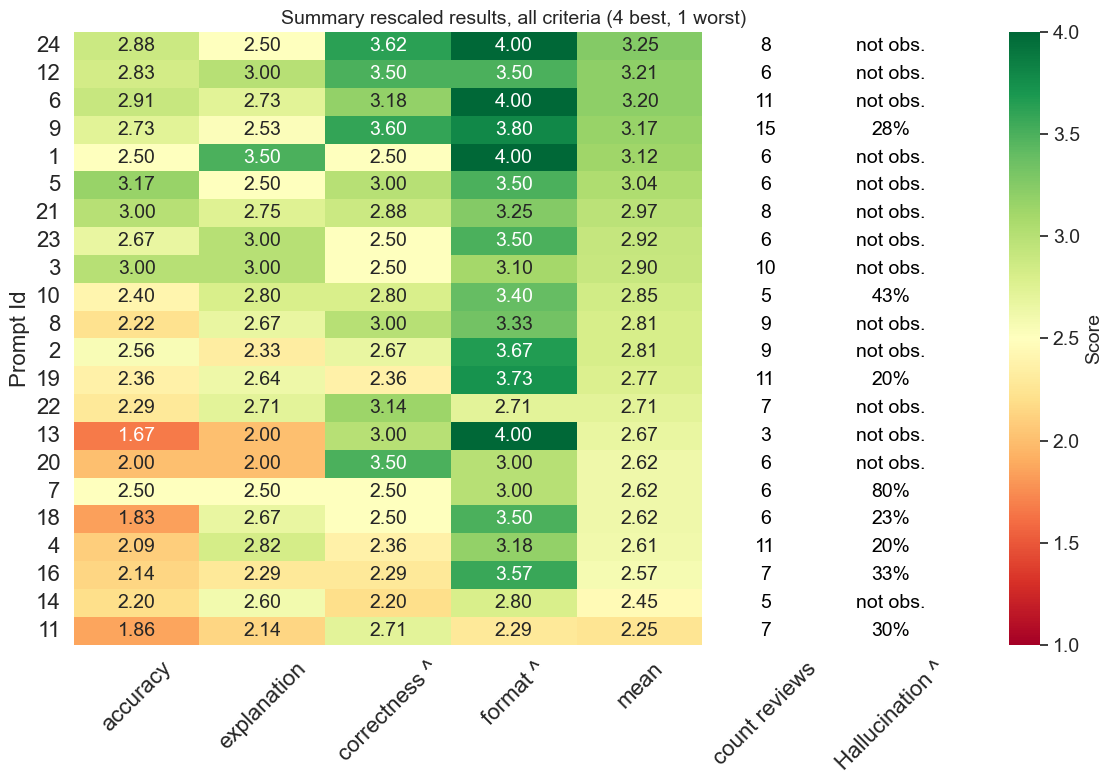

In [134]:
# Create a heatmap of grouped_results
import numpy as np

hallucination_results_formatted = summary_citations_by_prompt['Hallucination rate'].copy()
hallucination_results_formatted = hallucination_results_formatted.fillna(0)
grouped_results_4.loc[:,'Hallucination rate'] = hallucination_results_formatted
# grouped_results_4.loc[:,'Hallucination rate formatted'] = grouped_results_4.loc[:,'Hallucination rate'].astype(str)
# grouped_results_4.loc[grouped_results_4['Hallucination rate']>0,'Hallucination rate formatted'] = grouped_results_4.loc[grouped_results_4['Hallucination rate']>0,'Hallucination rate']
# grouped_results_4.loc[grouped_results_4['Hallucination rate']==0,'Hallucination rate formatted'] = grouped_results_4.loc[grouped_results_4['Hallucination rate']==0,'count reviews'].apply(lambda x: 1. / x) # Calculate upper bound on hallucination rate. Later on we'll add this an upper bound symbol to the heatmap.
if 'Hallucination rate' in grouped_results_4.columns:
    del grouped_results_4['Hallucination rate']
grouped_results_4.rename({'Hallucination rate formatted':'hallucination'}, axis=1, inplace=True)
plt.figure(figsize=(12, 8))

# Reset index to make prompt_id and prompt_id regular columns for easier plotting
grouped_results_reset = grouped_results_4.reset_index()
# Create the heatmap
mask = np.zeros(grouped_results_4.shape)
mask[:,-2] = True
mask[:,-1] = True
ax = sns.heatmap(grouped_results_4, mask=mask, annot=True, cmap='RdYlGn', vmin=1, vmax=4, fmt='.2f',
            cbar_kws={'label': 'Score'},
             annot_kws={"size": 14})
ax.collections[0].colorbar.ax.tick_params(labelsize=14)
ax.collections[0].colorbar.set_label('Score', fontsize=14)

plt.grid(False)
plt.title('Summary rescaled results, all criteria (4 best, 1 worst)',fontsize=14)
plt.xlabel('')
plt.ylabel('Prompt Id', fontsize=16)

# Add missing labels for the masked column
for (j,i), label in np.ndenumerate(grouped_results_4.values):
    if i == grouped_results_4.shape[1]-2:
        ax.text(i+0.5, j+0.5, f'{label:.0f}',
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))
    if i == grouped_results_4.shape[1]-1:
        if label == 0:
            label_formatted = 'not obs.'
        else:
            label_formatted = f'{label:.0%}'
        ax.text(i+0.5, j+0.5, label_formatted,
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))

# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_yticklabels()]
plt.xticks(rotation=45,fontsize=16)
plt.yticks(ax.get_yticks(), formatted_labels, rotation=0,ha='right',fontsize=16)

plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_all_criteria_per_prompt.png')
plt.show()


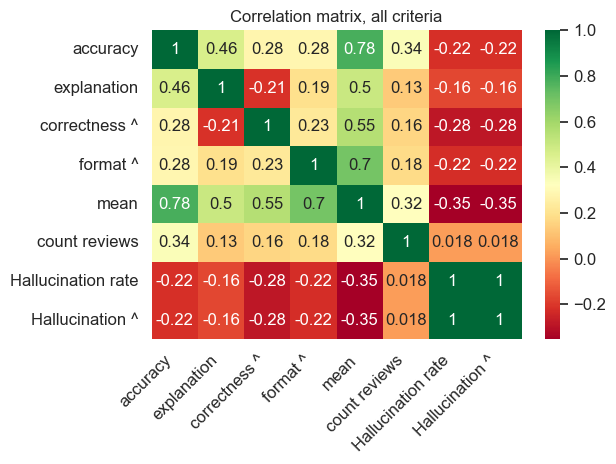

In [129]:
plt.figure()
grouped_results_4['Hallucination ^'] = grouped_results_4['Hallucination rate']
plt.title('Correlation matrix, all criteria',fontsize=12)
ax = sns.heatmap(grouped_results_4.corr(), annot=True, cmap='RdYlGn')
plt.xticks(rotation=45,ha='right',fontsize=12)
plt.yticks(fontsize=12)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(output_dir / f'{datestamp}_heatmap_all_criteria_corr.png')